In [1]:
import tensorflow as tf
from keras.utils import to_categorical
from keras import layers, models, optimizers, metrics, regularizers
import datetime


import sys
sys.path.append('..')
from scripts.prepare_data import download_data, preproces_baseline_forest, preproces_without_oversampling, augment_minority_classes, augment_to_target_counts
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import numpy as np

2026-01-15 19:16:32.465260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 19:16:32.496386: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 19:16:33.267583: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 19:16:33.267583: I tensorflow/core/util/port.cc:153] oneDNN custom operations ar

In [3]:
df_base_preproc = download_data()
#X_train, X_test, y_train, y_test = preproces_baseline_forest(df_base_preproc)
X_train, X_test, y_train, y_test = preproces_without_oversampling(df_base_preproc)

In [4]:
time_steps = X_train.shape[1]
features = 1

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
X_test_arr = X_test.values if hasattr(X_test, 'values') else X_test

X_train_preproc = X_train_arr.reshape((X_train.shape[0], time_steps, features))
X_test_preproc = X_test_arr.reshape((X_test.shape[0], time_steps, features))

# #augment
# X_train_aug, y_train_aug = augment_minority_classes(X_train_preproc, y_train)

y_train_numpy = y_train.values if hasattr(y_train, 'values') else y_train
X_train_aug, y_train_aug = augment_to_target_counts(X_train_preproc, y_train_numpy, {2:16000, 3:16000})
perm = np.random.permutation(len(X_train_aug))
X_train_preproc = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

# y_train_preproc = y_train

batch_size = 32

y_train_preproc = to_categorical(y_train_aug)
y_test_preproc = to_categorical(y_test)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_preproc, y_train_preproc)) \
    .shuffle(1000) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test_preproc, y_test_preproc)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

Stan początkowy: {np.int64(0): np.int64(122837), np.int64(1): np.int64(16000), np.int64(2): np.int64(1566), np.int64(3): np.int64(175)}
Klasa 0: Brak celu w słowniku. Pozostaje bez zmian (122837).
Klasa 1: Brak celu w słowniku. Pozostaje bez zmian (16000).
Klasa 2: Augmentacja z 1566 do 16000 (+14434 próbek)
Klasa 3: Augmentacja z 175 do 16000 (+15825 próbek)
Klasa 3: Augmentacja z 175 do 16000 (+15825 próbek)


I0000 00:00:1768501008.007565   84961 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9688 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Klasa 0: Oryginał 89 -> Generuję 89 nowych próbek (Razem: 178)
Klasa 1: Oryginał 9 -> Generuję 9 nowych próbek (Razem: 18)
Klasa 2: Oryginał 2 -> Generuję 2 nowych próbek (Razem: 4)


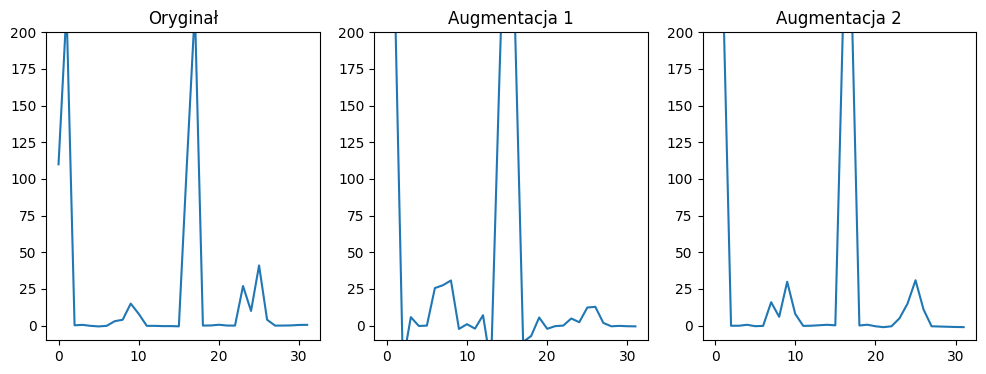

In [5]:
import matplotlib.pyplot as plt

X_test_aug, y_test_aug = augment_minority_classes(X_train_preproc[:100], y_train[:100])

plt.figure(figsize=(12, 4))

# Oryginał
plt.subplot(1, 3, 1)
plt.plot(X_train_preproc[0])
plt.title("Oryginał")
plt.ylim(-10, 200)

# Augmentacja 1
plt.subplot(1, 3, 2)
plt.plot(X_test_aug[105])
plt.title("Augmentacja 1")
plt.ylim(-10, 200)

# Augmentacja 2
plt.subplot(1, 3, 3)
plt.plot(X_test_aug[110])
plt.title("Augmentacja 2")
plt.ylim(-10, 200)

plt.show()

In [5]:

# AKTUALNIE CHYBA NAJLEPSZA SIEĆ - CONSISTENTLY OK 80%
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),
    
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),  
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.001),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=30,
                       callbacks=[
                           tensorboard_callback, 
                        #    early_stopping
                        ],
                       )

deep_rnn.save("models/1d_cnn.keras")

Epoch 1/30


2026-01-15 19:07:05.034964: I external/local_xla/xla/service/service.cc:163] XLA service 0x7966f4003ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-15 19:07:05.034976: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-15 19:07:05.058275: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-15 19:07:05.198151: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


  59/5339 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - f1_score: 0.3447 - loss: 1.1753

I0000 00:00:1768500426.749330   76695 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5339/5339 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - f1_score: 0.8684 - loss: 0.2180 - val_f1_score: 0.7255 - val_loss: 0.0609
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - f1_score: 0.8684 - loss: 0.2180 - val_f1_score: 0.7255 - val_loss: 0.0609
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9200 - loss: 0.1416 - val_f1_score: 0.7375 - val_loss: 0.0595
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9200 - loss: 0.1416 - val_f1_score: 0.7375 - val_loss: 0.0595
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9305 - loss: 0.1221 - val_f1_score: 0.7543 - val_loss: 0.0524
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9305 - loss: 0.1221 - val_f1_score: 0.7543 - val_loss: 0.0524
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.9383 - loss: 0.1127 - val_f1_score: 0.7659 - val_loss: 0.0536
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.9383 - loss: 0.1127 - val

In [9]:

# AKTUALNIE CHYBA NAJLEPSZA SIEĆ - CONSISTENTLY OK 80%
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),
    
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),  
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.001),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=30,
                       callbacks=[
                           tensorboard_callback, 
                        #    early_stopping
                        ],
                       )

deep_rnn.save("models/1d_cnn.keras")

Epoch 1/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8379 - loss: 0.2621 - val_f1_score: 0.7314 - val_loss: 0.0679
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8379 - loss: 0.2621 - val_f1_score: 0.7314 - val_loss: 0.0679
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9056 - loss: 0.1615 - val_f1_score: 0.7689 - val_loss: 0.0544
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9056 - loss: 0.1615 - val_f1_score: 0.7689 - val_loss: 0.0544
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9209 - loss: 0.1396 - val_f1_score: 0.7617 - val_loss: 0.0539
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9209 - loss: 0.1396 - val_f1_score: 0.7617 - val_loss: 0.0539
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9251 - loss: 0.1306 - val_f1_score: 0.7776 - val_loss: 0.0457
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9251 - loss: 0

In [28]:

# TA SAMA ARCHITEKTURA CO POWYŻEJ ALE Z INNĄ FUNKCJĄ STRATY
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),
    
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),  
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_focal_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.001),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=30,
                       callbacks=[
                           tensorboard_callback, 
                        #    early_stopping
                        ],
                       )

deep_rnn.save("models/1d_cnn.keras")

Epoch 1/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8222 - loss: 0.0348 - val_f1_score: 0.7442 - val_loss: 0.0089
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8222 - loss: 0.0348 - val_f1_score: 0.7442 - val_loss: 0.0089
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.8896 - loss: 0.0196 - val_f1_score: 0.7456 - val_loss: 0.0084
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.8896 - loss: 0.0196 - val_f1_score: 0.7456 - val_loss: 0.0084
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - f1_score: 0.9075 - loss: 0.0162 - val_f1_score: 0.7587 - val_loss: 0.0075
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - f1_score: 0.9075 - loss: 0.0162 - val_f1_score: 0.7587 - val_loss: 0.0075
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - f1_score: 0.9143 - loss: 0.0149 - val_f1_score: 0.7401 - val_loss: 0.0073
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - f1_score: 0.9143 - loss: 0

In [8]:
# TA SAMA ARCHITEKTURA CO POWYŻEJ ALE Z INNĄ FUNKCJĄ STRATY
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_focal_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.001),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=30,
                       callbacks=[
                           tensorboard_callback, 
                        #    early_stopping
                        ],
                       )

deep_rnn.save("models/1d_cnn.keras")

Epoch 1/30


2026-01-15 19:28:50.781343: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:28:50.919909: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_458', 4 bytes spill stores, 4 bytes spill loads



5311/5339 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.7515 - loss: 0.0419

2026-01-15 19:29:01.062303: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:29:01.238002: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_458', 4 bytes spill stores, 4 bytes spill loads



5339/5339 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - f1_score: 0.8002 - loss: 0.0292 - val_f1_score: 0.7129 - val_loss: 0.0077
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - f1_score: 0.8002 - loss: 0.0292 - val_f1_score: 0.7129 - val_loss: 0.0077
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8526 - loss: 0.0200 - val_f1_score: 0.7276 - val_loss: 0.0070
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8526 - loss: 0.0200 - val_f1_score: 0.7276 - val_loss: 0.0070
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8685 - loss: 0.0181 - val_f1_score: 0.7718 - val_loss: 0.0052
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8685 - loss: 0.0181 - val_f1_score: 0.7718 - val_loss: 0.0052
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8720 - loss: 0.0173 - val_f1_score: 0.7499 - val_loss: 0.0056
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8720 - loss: 0.0173 - val